In [1]:
import jax
import jax.numpy as jnp
from jax import grad


In [2]:
grad_tanh = grad(jnp.tanh)

In [3]:
print(grad_tanh)

<function tanh at 0x7fd3e9951fe0>


In [4]:
print(jax.make_jaxpr(grad_tanh))

<function make_jaxpr(tanh) at 0x7fd3e9952140>


In [5]:
print(jax.make_jaxpr(grad_tanh)(2.0))

{ lambda ; a:f32[]. let
    b:f32[] = tanh a
    c:f32[] = sub 1.0:f32[] b
    d:f32[] = mul 1.0:f32[] c
    e:f32[] = mul d b
    f:f32[] = add_any d e
  in (f,) }


In [6]:
print(grad_tanh(2.0))

0.070650935


In [7]:
print(grad_tanh)

<function tanh at 0x7fd3e9951fe0>


In [8]:
print(grad(grad(jnp.tanh))(2.0))

-0.13621888


In [9]:
print(grad(grad(grad(jnp.tanh)))(2.0))

0.2526544


In [10]:
def f(x):
    return x ** 3 + 2 * x ** 2 - 3 * x + 1

In [11]:
dfdx = grad(f)

In [12]:
dfdx(1.0)

Array(4., dtype=float32, weak_type=True)

In [13]:
d2fdx = jax.grad(dfdx)
d3fdx = jax.grad(d2fdx)
d4fdx = jax.grad(d3fdx)

In [14]:
print(dfdx(1.))
print(d2fdx(1.))
print(d3fdx(1.))
print(d4fdx(1.))

4.0
10.0
6.0
0.0


In [15]:
def sigmoid(x):
    return 0.5 * (jnp.tanh(x / 2) + 1)
    

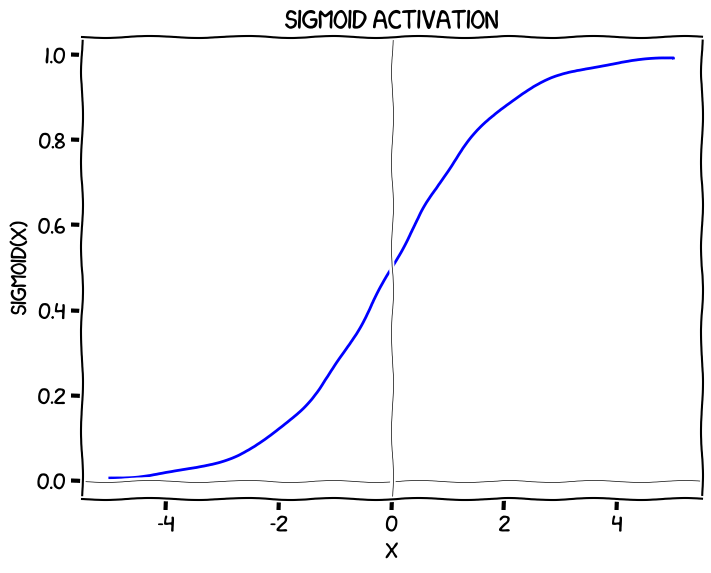

In [16]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

plt.xkcd()
font_family = None
for f in font_manager.fontManager.ttflist:
    if "xkcd" in f.name.lower():
        font_family = f.name
        break
if font_family is not None:
    plt.rcParams['font.family'] = font_family

x = jnp.linspace(-5, 5, 200)
y = sigmoid(x)

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.plot(np.asarray(x), np.asarray(y), 'b-', linewidth=2)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('X')
ax.set_ylabel('SIGMOID(X)')
ax.set_title('SIGMOID ACTIVATION')
plt.show()

In [17]:
key = jax.random.key(0)

In [18]:
def predict(W, b, inputs):
    return sigmoid(jnp.dot(inputs, W) + b)

In [19]:
inputs = jnp.array([
    [0.52, 1.12, 0.77],
    [0.88, -1.08, 0.15],
    [0.52, 0.06, -1.30],
    [0.74, -2.49, 1.39],
])
targets = jnp.array([True, True, False, True])

In [20]:
def loss(W, b):
    preds = predict(W, b, inputs)
    label_probs = preds * targets + (1 - preds) * (1 - targets)
    return -jnp.sum(jnp.log(label_probs))

In [21]:
key, W_key, b_key = jax.random.split(key, 3)
W = jax.random.normal(W_key, (3,))
b = jax.random.normal(b_key, ())

In [22]:
W_grad = grad(loss, argnums=0)(W, b)
print(f"{W_grad=}")

W_grad=Array([-0.43314588, -0.7354602 , -1.2598921 ], dtype=float32)


In [23]:
W_grad = grad(loss)(W, b)
print(f"{W_grad=}")

W_grad=Array([-0.43314588, -0.7354602 , -1.2598921 ], dtype=float32)


In [24]:
b_grad = grad(loss, 1)(W, b)
print(f"{b_grad=}")

b_grad=Array(-0.6900176, dtype=float32)


In [25]:
W_grad, b_grad = grad(loss, (0, 1))(W, b)
print(f"{W_grad=}")
print(f"{b_grad=}")

W_grad=Array([-0.43314588, -0.7354602 , -1.2598921 ], dtype=float32)
b_grad=Array(-0.6900176, dtype=float32)


In [26]:
def loss2(params_dict):
    preds = predict(params_dict["W"], params_dict["b"], inputs)
    label_probs = preds * targets + (1 - preds) * (1 - targets)
    return -jnp.sum(jnp.log(label_probs))

print(grad(loss2)({"W": W, "b": b}))

{'W': Array([-0.43314588, -0.7354602 , -1.2598921 ], dtype=float32), 'b': Array(-0.6900176, dtype=float32)}


In [27]:
loss_value, Wb_grad = jax.value_and_grad(loss, (0, 1))(W, b)
print("Loss value", loss_value)
print(f"{Wb_grad=}")
print("Loss value", loss(W, b))

Loss value 2.9729185
Wb_grad=(Array([-0.43314588, -0.7354602 , -1.2598921 ], dtype=float32), Array(-0.6900176, dtype=float32))
Loss value 2.9729185


In [28]:
eps = 1e-4

b_grad_numerical = (loss(W, b + eps / 2.) - loss(W, b - eps / 2.)) / eps
print(f"{b_grad_numerical=}")
b_grad_autodiff = grad(loss, 1)(W, b)
print(f"{b_grad_autodiff=}")

b_grad_numerical=Array(-0.6866455, dtype=float32)
b_grad_autodiff=Array(-0.6900176, dtype=float32)


In [29]:
key, subkey = jax.random.split(key)
vec = jax.random.normal(subkey, W.shape)
print(f"{vec=}")

vec=Array([-1.2574775, -0.4016044, -1.1213602], dtype=float32)


In [30]:
unitvec = vec / jnp.sqrt(jnp.vdot(vec, vec))
print(f"{unitvec=}")

unitvec=Array([-0.72600687, -0.23186702, -0.6474193 ], dtype=float32)


In [31]:
W_grad_numerical = (loss(W + eps / 2. * unitvec, b) - loss(W - eps / 2. * unitvec, b)) / eps
print(f"{W_grad_numerical=}")
W_grad_autodiff_size = jnp.vdot(grad(loss)(W, b), unitvec)
print(f"{W_grad_autodiff_size=}")

W_grad_numerical=Array(1.2993813, dtype=float32)
W_grad_autodiff_size=Array(1.3006742, dtype=float32)


In [33]:
from jax.test_util import check_grads

print(check_grads(loss, (W, b), order=2))

None
